In [ ]:
"""
We want to scale values that are in a range [min, max] in a range [a, b] .

        (b − a) ⋅ (x − min)
f(x) =  --------------------- +  a
            max − min

We now use this formula to transform both the X and Y coordinates of data into other ranges:
"""

In [2]:
import numpy as np
import sklearn.datasets as ds
import matplotlib.pyplot as plt

min_x_new, max_x_new = 33, 88
min_y_new, max_y_new = 12, 20

data, labels = ds.make_moons(n_samples=100,
                             shuffle=True,       # Whether to shuffle the samples
                             noise=0.05,         # Standard deviation of Gaussian noise added to the data
                             random_state=None)


In [3]:
data.shape, labels.shape

((100, 2), (100,))

In [5]:
data , labels

(array([[ 1.01947447e+00,  3.01051519e-03],
        [ 5.39818016e-01,  8.31252598e-01],
        [-9.22592705e-01,  2.92885060e-01],
        [ 8.58353235e-01,  5.24897486e-01],
        [ 2.65794187e-01, -2.48143325e-01],
        [ 7.93934164e-01,  6.08348242e-01],
        [-9.43087286e-01,  1.94396974e-01],
        [ 1.94498528e+00,  3.89480975e-02],
        [ 1.36469189e-01,  1.05457468e+00],
        [ 3.80050532e-01,  8.59792058e-01],
        [ 3.08353886e-01,  9.01562573e-01],
        [ 7.80083910e-01, -5.07217498e-01],
        [ 9.87717430e-02,  9.56019446e-01],
        [ 6.32930294e-01,  7.87375104e-01],
        [-9.84545438e-01,  4.90958229e-02],
        [ 8.98973384e-01,  3.92523162e-01],
        [ 5.08805954e-01,  9.46564893e-01],
        [ 3.94270633e-01, -1.81770821e-01],
        [ 6.60109926e-01, -4.40395893e-01],
        [ 9.76793129e-01, -4.30651994e-02],
        [ 2.13875233e-01, -2.35202392e-01],
        [ 2.71329565e-01, -1.56949955e-01],
        [ 6.81098726e-01,  6.968

In [6]:
np.bincount(labels)

array([50, 50], dtype=int64)

In [7]:
min_x, min_y = np.ndarray.min(data[:, 0]), np.ndarray.min(data[:, 1])
min_x, min_y

(-0.9845454379939464, -0.5911994045115477)

In [8]:
max_x, max_y = np.ndarray.max(data[:, 0]), np.ndarray.max(data[:, 1])
max_x, max_y

(2.0850289225631986, 1.075958615170072)

In [ ]:
# data -= np.array([min_x, 0])
# data *= np.array([max_x_new - min_x_new / (max_x - min_x), 1])
# data += np.array([min_x_new, 0])
# data -= np.array([0, min_y])
# data *= np.array([1, (max_y_new - min_y_new) / (max_y - min_y)])
# data += np.array([0, min_y_new])

In [10]:
data -= np.array([min_x, min_y])
data *= np.array([(max_x_new - min_x_new) / (max_x - min_x), (max_y_new - min_y_new) / max_y - min_y])
data += np.array([min_x_new, min_y_new])

In [11]:
def scale_data(data, new_limits, inplace=False):
    if not inplace:
        data = data.copy()
        min_x, min_y = np.ndarray.min(data[:, 0]), np.ndarray.min(data[:, 1])
        max_x, max_y = np.ndarray.max(data[:, 0]), np.ndarray.max(data[:, 1])
        
        min_x_new, max_x_new = new_limits[0]
        min_y_new, max_y_new = new_limits[1]
        
        data -= np.array([min_x, min_y])
        data *= np.array([(max_x_new - min_x_new) / (max_x - min_x), (max_y_new - min_y_new) / (max_y - min_y)])
        data += np.array([min_x_new, min_y_new])
        
        if inplace:
            return None
        else:
            return data
              
    

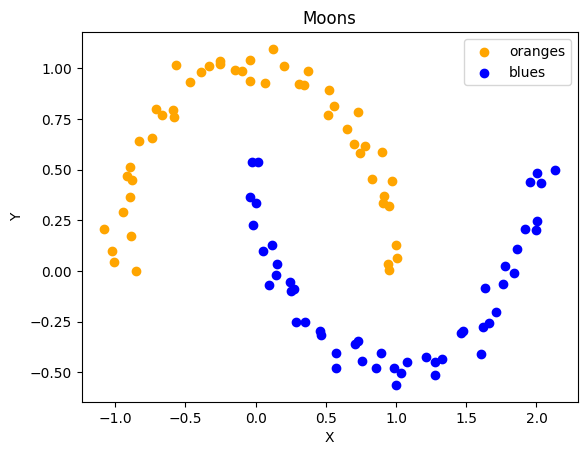

In [12]:
data, labels = ds.make_moons(n_samples=100,
                             shuffle=True,
                             noise=0.05,
                             random_state=None)

scale_data(data, [(1, 4), (3, 8)], inplace=True)

fig, ax = plt.subplots()

ax.scatter(data[labels == 0, 0], data[labels == 0, 1], c='orange', label='oranges')
ax.scatter(data[labels == 1, 0], data[labels == 1, 1], c='blue', label='blues')

ax.set(xlabel='X', ylabel='Y', title='Moons')
ax.legend(loc='upper right')
plt.show()